In [30]:
# Install required libraries (run once)
!pip install pygwalker pandas numpy matplotlib seaborn scikit-learn mlxtend wordcloud networkx

In [31]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pygwalker as pyg

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings

import matplotlib.cm as cm

import networkx as nx
 
from collections import Counter
from itertools import combinations
from wordcloud import WordCloud
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [3]:
# -------------------------------------------------------
# LOAD DATASET
# -------------------------------------------------------
df = pd.read_csv('data/Social Media Engagement Dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (12000, 28)
Columns: ['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id', 'location', 'language', 'text_content', 'hashtags', 'mentions', 'keywords', 'topic_category', 'sentiment_score', 'sentiment_label', 'emotion_type', 'toxicity_score', 'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate', 'brand_name', 'product_name', 'campaign_name', 'campaign_phase', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate']


,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [4]:
# Basic info and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  str    
 1   timestamp                12000 non-null  str    
 2   day_of_week              12000 non-null  str    
 3   platform                 12000 non-null  str    
 4   user_id                  12000 non-null  str    
 5   location                 12000 non-null  str    
 6   language                 12000 non-null  str    
 7   text_content             12000 non-null  str    
 8   hashtags                 12000 non-null  str    
 9   mentions                 8059 non-null   str    
 10  keywords                 12000 non-null  str    
 11  topic_category           12000 non-null  str    
 12  sentiment_score          12000 non-null  float64
 13  sentiment_label          12000 non-null  str    
 14  emotion_type             12000 no

In [5]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
mentions    3941
dtype: int64


In [6]:
# -------------------------------------------------------
# PREPROCESSING STEPS
# -------------------------------------------------------

df_clean = df.copy()

# 1. Drop duplicates
df_clean = df_clean.drop_duplicates()
print(f'Rows after deduplication: {len(df_clean)}')

# 2. Fill or drop missing values
df_clean = df_clean.dropna()
print(f'Rows after dropping nulls: {len(df_clean)}')

# 3. Parse datetime column
date_col = 'timestamp'
if date_col in df_clean.columns:
    df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors='coerce')
    df_clean['Month'] = df_clean[date_col].dt.month
    df_clean['Hour'] = df_clean[date_col].dt.hour
    print('Datetime features extracted: Hour, Month')

# 4. Encode categorical columns for ML (create a copy with numeric encoding)
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns detected: {cat_cols}')

df_encoded = df_clean.copy()
for col in cat_cols:
    df_encoded[col + '_enc'] = le.fit_transform(df_clean[col].astype(str))

print('\nPreprocessing complete!')
df_clean.head()

Rows after deduplication: 12000
Rows after dropping nulls: 8059
Datetime features extracted: Hour, Month
Categorical columns detected: ['post_id', 'day_of_week', 'platform', 'user_id', 'location', 'language', 'text_content', 'hashtags', 'mentions', 'keywords', 'topic_category', 'sentiment_label', 'emotion_type', 'brand_name', 'product_name', 'campaign_name', 'campaign_phase']

Preprocessing complete!


,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,Month,Hour
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6,7,19
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5,9,4
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8,9,21
7,wu063ci6mizp,2025-01-27 16:09:54,Monday,Reddit,user_2es9a4lv,"São Paulo, Brazil",es,Just saw an ad for Coca-Cola Coke Zero during ...,"#MustHave, #Discount","@MarketingTeam, @InfluencerName",...,0.04442,Coca-Cola,Coke Zero,CustomerFirst,Post-Launch,-0.9831,0.2152,89.7,1,16
8,9q2i3owe4tv9,2024-11-29 17:03:41,Friday,Reddit,user_omh7bn2t,"Milan, Italy",ru,Just tried the Coke Zero from Coca-Cola. Absol...,"#Deal, #Fashion",@TrendSetter,...,0.03274,Coca-Cola,Coke Zero,SpringBlast2025,Launch,-0.8119,-0.1949,-29.0,11,17


In [7]:
# Summary statistics
df_clean.describe()

,timestamp,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,Month,Hour
count,8059,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000,8059.000000
mean,2024-10-30 15:54:18.542127,0.002675,0.505968,2471.731232,1002.708773,505.672540,49655.051371,0.286367,-0.002034,0.000891,0.682070,6.523638,11.476858
min,2024-05-01 01:04:04,-0.999800,0.000000,1.000000,0.000000,0.000000,135.000000,0.001880,-0.999600,-0.499900,-99.900000,1.000000,0.000000
25%,2024-07-31 03:42:19.500000,-0.499400,0.257100,1217.500000,509.000000,252.000000,24586.000000,0.048950,-0.502400,-0.246650,-48.600000,4.000000,6.000000
50%,2024-10-31 20:56:52,0.001000,0.508100,2472.000000,1009.000000,507.000000,49558.000000,0.080800,-0.001300,0.002500,0.600000,7.000000,11.000000
75%,2025-01-29 16:15:29,0.515350,0.756850,3699.500000,1490.000000,758.000000,74776.500000,0.163970,0.504100,0.249200,50.100000,10.000000,17.000000
max,2025-04-30 21:57:10,0.999800,0.999900,5000.000000,2000.000000,1000.000000,99964.000000,32.211710,0.999400,0.499500,99.900000,12.000000,23.000000
std,NaN,0.582688,0.286841,1442.161090,573.072722,289.541062,28973.997431,1.209613,0.578780,0.289152,57.716254,3.458908,6.932720


In [8]:
# Basic info and data types
df_clean.info()

<class 'pandas.DataFrame'>
Index: 8059 entries, 1 to 11999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   post_id                  8059 non-null   str           
 1   timestamp                8059 non-null   datetime64[us]
 2   day_of_week              8059 non-null   str           
 3   platform                 8059 non-null   str           
 4   user_id                  8059 non-null   str           
 5   location                 8059 non-null   str           
 6   language                 8059 non-null   str           
 7   text_content             8059 non-null   str           
 8   hashtags                 8059 non-null   str           
 9   mentions                 8059 non-null   str           
 10  keywords                 8059 non-null   str           
 11  topic_category           8059 non-null   str           
 12  sentiment_score          8059 non-null   float64 

---
## Exploratory Data Analysis with PyGWalker

PyGWalker opens an **interactive Tableau-style interface** directly in the notebook.  
**How to explore:**
- Drag columns to X/Y axes
- Drag a column to **Color** for color-coded grouping
- Use the **Filter** box to isolate a platform or time window
- Switch chart types using the toolbar
- Export charts as PNG or SVG for your report

In [9]:
# Launch interactive PyGWalker dashboard
walker = pyg.walk(df_clean)

# -------------------------------------------------------
# SUGGESTED CHARTS TO BUILD IN THE INTERFACE:
#
# Chart 1 — Bar: Platform (X) vs. Avg Likes (Y)
#                Which platform drives most engagement?
#
# Chart 2 — Scatter: Sentiment Label (X) vs. Share Count (Y)
#                    Color by Emotion Type
#                    Do Positive posts always share more?
#
# Chart 3 — Bar: Location (X) vs. Toxicity Score (Y)
#                Color by language or topic category
#                Which location has the highest toxicity?
#
# Chart 4 — Line: Hour (X) vs. Avg Engagement Rate (Y)
#                 Best time of day to post
#
# Chart 5 — Heatmap: Day_of_Week (X) vs. Platform (Y)
#                    Color = Avg Engagement Rate
# -------------------------------------------------------

Box(children=(HTML(value='\n<div id="ifr-pyg-0006500112883b2az3Plo2GeYZdyxjLN" style="height: auto">\n    <hea…

---
## Correlation Analysis

Numeric columns: ['sentiment_score', 'toxicity_score', 'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate', 'Month', 'Hour']


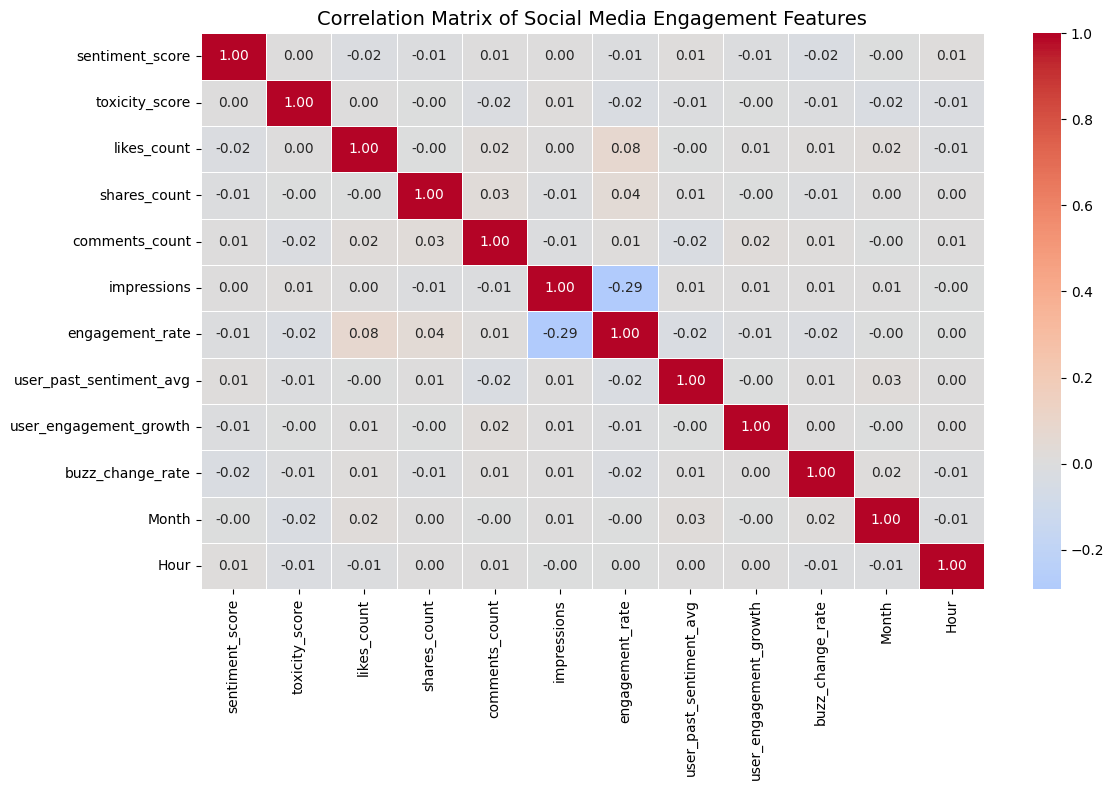

Saved: correlation_matrix.png


In [10]:
# Select numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric columns: {numeric_cols}')

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Matrix of Social Media Engagement Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()
print('Saved: correlation_matrix.png')

In [11]:
# Find top correlated pairs with engagement rate
target_col = 'engagement_rate'

if target_col in corr_matrix.columns:
    top_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
    print(f'Top correlations with {target_col}:')
    print(top_corr)

Top correlations with engagement_rate:
likes_count                0.075616
shares_count               0.043217
comments_count             0.011309
Hour                       0.000466
Month                     -0.003297
user_engagement_growth    -0.007801
sentiment_score           -0.010269
buzz_change_rate          -0.017930
user_past_sentiment_avg   -0.019760
toxicity_score            -0.022139
impressions               -0.292204
Name: engagement_rate, dtype: float64


---
## Association Rule Mining (Apriori)

Find patterns like: *"Posts tagged as video + posted in evening → high engagement"*

In [12]:
# -------------------------------------------------------
# Prepare data for Apriori
# We bin numeric features into categories and combine with
# existing categorical features to form transaction items
# -------------------------------------------------------

df_arm = df_clean.copy()

# Bin engagement rate into Low / Medium / High (adjust column name)
if 'engagement_rate' in df_arm.columns:
    df_arm['Engagement_Level'] = pd.qcut(
        df_arm['engagement_rate'],
        q=3,
        labels=['Low_Engagement', 'Medium_Engagement', 'High_Engagement']
    )

# Bin likes into buckets
if 'likes_count' in df_arm.columns:
    df_arm['Likes_Level'] = pd.qcut(
        df_arm['likes_count'], q=3,
        labels=['Low_Likes', 'Medium_Likes', 'High_Likes']
    )

# Build transaction list
# -------------------------------------------------------
# Adjust these column names to match your dataset
# -------------------------------------------------------
transaction_cols = []
for col in ['platform', 'topic_category', 'Hour', 'Month', 'sentiment_label','brand_name', 'Engagement_Level', 'Likes_Level']:
    if col in df_arm.columns:
        transaction_cols.append(col)

print(f'Building transactions from: {transaction_cols}')

transactions = df_arm[transaction_cols].astype(str).values.tolist()
print(f'Total transactions: {len(transactions)}')
print(f'Sample transaction: {transactions[0]}')

Building transactions from: ['platform', 'topic_category', 'Hour', 'Month', 'sentiment_label', 'brand_name', 'Engagement_Level', 'Likes_Level']
Total transactions: 8059
Sample transaction: ['Twitter', 'Delivery', '19', '7', 'Negative', 'Microsoft', 'Low_Engagement', 'Low_Likes']


In [13]:
# One-hot encode transactions
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix shape: {df_te.shape}')
df_te.head()

Transaction matrix shape: (8059, 54)


,0,1,10,11,12,13,14,15,16,17,...,Positive,Pricing,Product,Reddit,Returns,Samsung,Support,Toyota,Twitter,YouTube
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,False,False,False,True,False,...,True,True,False,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,False,False,False


In [14]:
# Run Apriori
MIN_SUPPORT = 0.1  # tune this if you get too few/many rules

frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'Frequent itemsets found: {len(frequent_itemsets)}')
frequent_itemsets.sort_values('support', ascending=False).head(10)

Frequent itemsets found: 56


,support,itemsets,length
29,0.407371,frozenset({Positive}),1
25,0.405261,frozenset({Negative}),1
20,0.333540,frozenset({Low_Likes}),1
19,0.333416,frozenset({Low_Engagement}),1
22,0.333292,frozenset({Medium_Engagement}),1
16,0.333292,frozenset({High_Engagement}),1
17,0.333292,frozenset({High_Likes}),1
23,0.333168,frozenset({Medium_Likes}),1
37,0.203747,frozenset({YouTube}),1
45,0.201390,"frozenset({Low_Likes, Low_Engagement})",2


In [15]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.25)
rules = rules.sort_values('lift', ascending=False)

print(f'Total rules generated: {len(rules)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Total rules generated: 6


,antecedents,consequents,support,confidence,lift
5,frozenset({Low_Engagement}),frozenset({Low_Likes}),0.201390,0.604019,1.810935
4,frozenset({Low_Likes}),frozenset({Low_Engagement}),0.201390,0.603795,1.810935
1,frozenset({High_Engagement}),frozenset({High_Likes}),0.156719,0.470216,1.410823
0,frozenset({High_Likes}),frozenset({High_Engagement}),0.156719,0.470216,1.410823
3,frozenset({High_Likes}),frozenset({Medium_Engagement}),0.150391,0.451229,1.353854
2,frozenset({Medium_Engagement}),frozenset({High_Likes}),0.150391,0.451229,1.353854


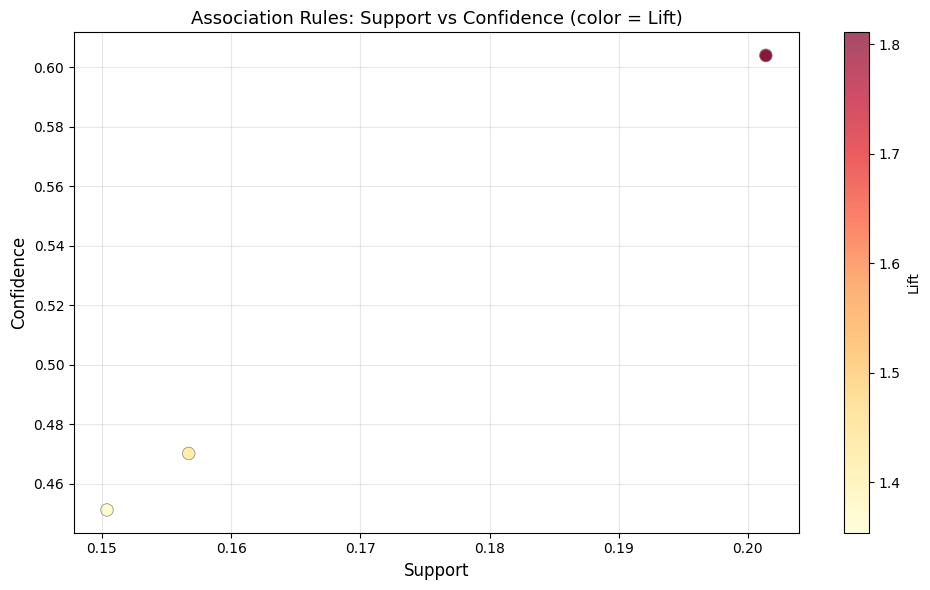

Saved: association_rules.png


In [16]:
# Visualize rules: Support vs. Confidence, colored by Lift
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    s=80,
    alpha=0.7,
    edgecolors='gray',
    linewidths=0.5
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules: Support vs Confidence (color = Lift)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('association_rules.png', dpi=150)
plt.show()
print('Saved: association_rules.png')

In [17]:
# Filter rules that lead to High Engagement (most interesting for the project)
high_eng_rules = rules[
    rules['consequents'].astype(str).str.contains('High_Engagement')
].sort_values('lift', ascending=False)

print('Rules leading to HIGH ENGAGEMENT:')
high_eng_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Rules leading to HIGH ENGAGEMENT:


,antecedents,consequents,support,confidence,lift
0,frozenset({High_Likes}),frozenset({High_Engagement}),0.156719,0.470216,1.410823


---
## Trend Analysis (Time-Based)

Identify the best times and days to post for maximum engagement.

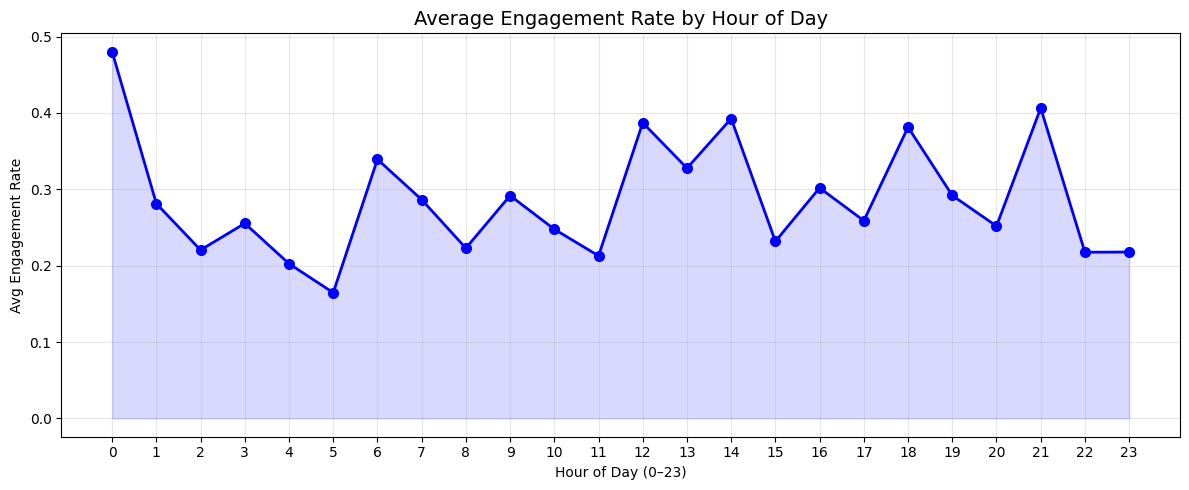

Peak hour: 0:00


In [18]:
# -------------------------------------------------------
# Engagement by Hour of Day
# -------------------------------------------------------
if 'Hour' in df_clean.columns and 'engagement_rate' in df_clean.columns:
    hourly = df_clean.groupby('Hour')['engagement_rate'].mean().reset_index()

    plt.figure(figsize=(12, 5))
    plt.plot(hourly['Hour'], hourly['engagement_rate'], 'b-o', linewidth=2, markersize=7)
    plt.fill_between(hourly['Hour'], hourly['engagement_rate'], alpha=0.15, color='blue')
    plt.title('Average Engagement Rate by Hour of Day', fontsize=14)
    plt.xlabel('Hour of Day (0–23)')
    plt.ylabel('Avg Engagement Rate')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('engagement_by_hour.png', dpi=150)
    plt.show()
    print(f'Peak hour: {hourly.loc[hourly["engagement_rate"].idxmax(), "Hour"]}:00')
else:
    print('Hour or Engagement_Rate column not found. Check column names.')

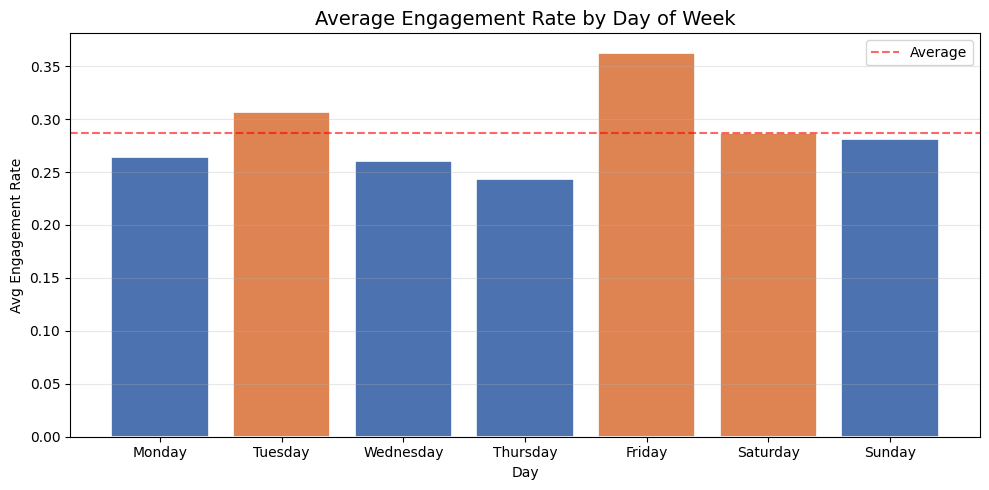

Best day: Friday


In [19]:
# Engagement by Day of Week
if 'day_of_week' in df_clean.columns and 'engagement_rate' in df_clean.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily = df_clean.groupby('day_of_week')['engagement_rate'].mean().reindex(day_order)

    colors = ['#4C72B0' if v < daily.mean() else '#DD8452' for v in daily.values]
    plt.figure(figsize=(10, 5))
    bars = plt.bar(daily.index, daily.values, color=colors, edgecolor='white', linewidth=1.2)
    plt.axhline(y=daily.mean(), color='red', linestyle='--', alpha=0.6, label='Average')
    plt.title('Average Engagement Rate by Day of Week', fontsize=14)
    plt.xlabel('Day')
    plt.ylabel('Avg Engagement Rate')
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('engagement_by_day.png', dpi=150)
    plt.show()
    print(f'Best day: {daily.idxmax()}')
else:
    print('ℹDay_of_Week or Engagement_Rate column not found. Check preprocessing.')

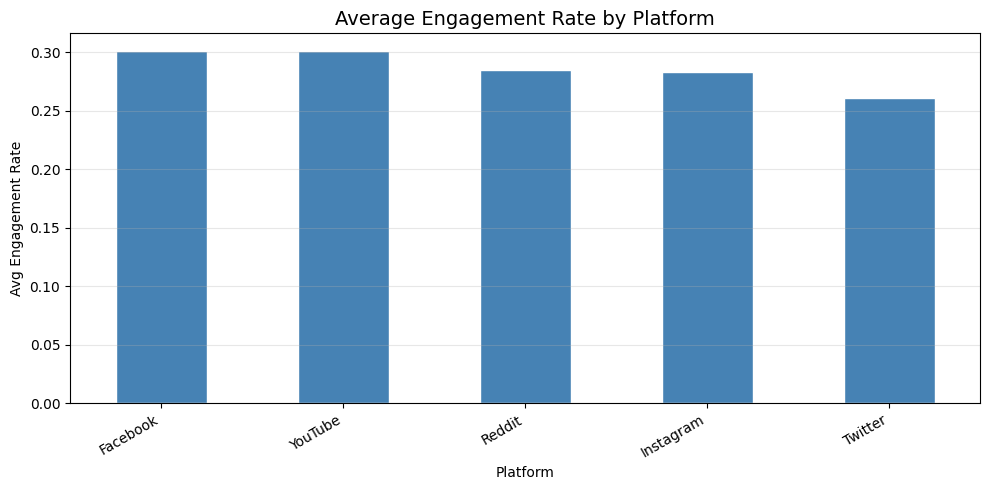

In [20]:
# Platform-wise engagement trends (bar chart)
platform_col = 'platform'

if platform_col in df_clean.columns and 'engagement_rate' in df_clean.columns:
    platform_eng = df_clean.groupby(platform_col)['engagement_rate'].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    platform_eng.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Average Engagement Rate by Platform', fontsize=14)
    plt.xlabel('Platform')
    plt.ylabel('Avg Engagement Rate')
    plt.xticks(rotation=30, ha='right')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('engagement_by_platform.png', dpi=150)
    plt.show()

In [21]:
# Interactive trend exploration with PyGWalker
# Drag Hour to X, Engagement_Rate to Y, Platform to Color → Line chart
# Switch platform filter to compare trends across platforms
print(' Explore trends interactively below.')
print(' Suggested: X=Hour, Y=Engagement_Rate, Color=Platform → Line chart')
pyg.walk(df_clean)

 Explore trends interactively below.
 Suggested: X=Hour, Y=Engagement_Rate, Color=Platform → Line chart


Box(children=(HTML(value='\n<div id="ifr-pyg-00065001129a6097PxpYfqgFai5Q6B0b" style="height: auto">\n    <hea…

In [46]:
def parse_hashtags(text):
    """
    Extract individual hashtags from a string.
    """
    if pd.isna(text):
        return []
    tokens = str(text).split(",")
    tags = []
    for t in tokens:
        t = t.strip().lower()          # remove leading/trailing spaces
        if not t.startswith("#"):
            t = "#" + t                # ensure # prefix
        t = t.strip()
        if len(t) > 1:                 # ignore bare "#" tokens
            tags.append(t)
    return tags
 
df_clean["hashtag_list"] = df_clean["hashtags"].apply(parse_hashtags)
df_clean["hashtag_count_parsed"] = df_clean["hashtag_list"].apply(len)
 

#for raw, parsed in zip(df_clean["hashtags"].head(5), df_clean["hashtag_list"].head(5)):
#    print(f"  raw   : {raw}")
#    print(f"  parsed: {parsed}")
#    print()
 
# Explode: one row per hashtag (for per-tag analysis)
df_exploded = df_clean.explode("hashtag_list").rename(columns={"hashtag_list": "hashtag"})
df_exploded = df_exploded[df_exploded["hashtag"].notna() & (df_exploded["hashtag"] != "#")]
 
print(f"[PARSE] Total hashtag occurrences : {len(df_exploded)}")
print(f"[PARSE] Unique hashtags            : {df_exploded['hashtag'].nunique()}")
print(f"[PARSE] All unique hashtags        : {sorted(df_exploded['hashtag'].unique().tolist())}")

[PARSE] Total hashtag occurrences : 16196
[PARSE] Unique hashtags            : 29
[PARSE] All unique hashtags        : ['#affordable', '#beauty', '#bestvalue', '#customerservice', '#deal', '#discount', '#eco', '#exclusive', '#fashion', '#fitness', '#food', '#health', '#innovation', '#lifestyle', '#limited', '#musthave', '#newrelease', '#premium', '#productlaunch', '#promo', '#quality', '#reviews', '#sale', '#specialoffer', '#sustainable', '#tech', '#travel', '#trendalert', '#trending']



[ANALYSIS 1] Top Hashtags by Frequency
         Hashtag  Count
        #fitness    620
        #premium    589
       #musthave    584
        #reviews    584
    #sustainable    584
      #bestvalue    584
            #eco    581
       #trending    579
   #specialoffer    577
  #productlaunch    568
     #trendalert    564
     #affordable    562
           #deal    561
#customerservice    560
           #food    559
         #health    558
        #fashion    558
         #beauty    557
          #promo    556
     #newrelease    554
      #lifestyle    551
           #tech    547
         #travel    543
        #quality    529
       #discount    520
           #sale    520
        #limited    520
      #exclusive    518
     #innovation    509


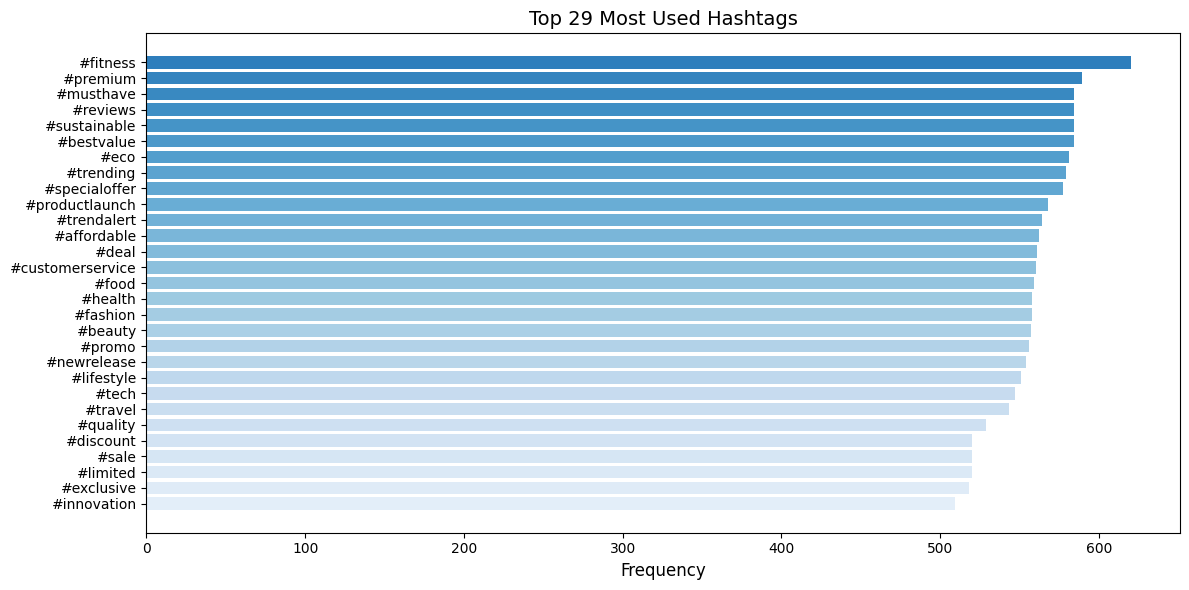

[ANALYSIS 1] Saved: hashtag_frequency.png


In [50]:
# -------------------------------------------------------------
# TOP HASHTAGS BY FREQUENCY
# -------------------------------------------------------------
print("\n[ANALYSIS 1] Top Hashtags by Frequency")
 
tag_counts = Counter(df_exploded["hashtag"].tolist())
top_tags   = pd.DataFrame(tag_counts.most_common(df_exploded['hashtag'].nunique()), columns=["Hashtag", "Count"])
 
print(top_tags.to_string(index=False))
 
plt.figure(figsize=(12, 6))
colors = cm.Blues_r(np.linspace(0.3, 0.9, len(top_tags)))
bars = plt.barh(top_tags["Hashtag"][::-1], top_tags["Count"][::-1], color=colors[::-1])
plt.xlabel("Frequency", fontsize=12)
plt.title("Top " + str(len(top_tags)) + " Most Used Hashtags", fontsize=14)
plt.tight_layout()
plt.savefig("hashtag_frequency.png", dpi=150)
plt.show()
print("[ANALYSIS 1] Saved: hashtag_frequency.png")


[ANALYSIS 2] Generating Hashtag Word Cloud...


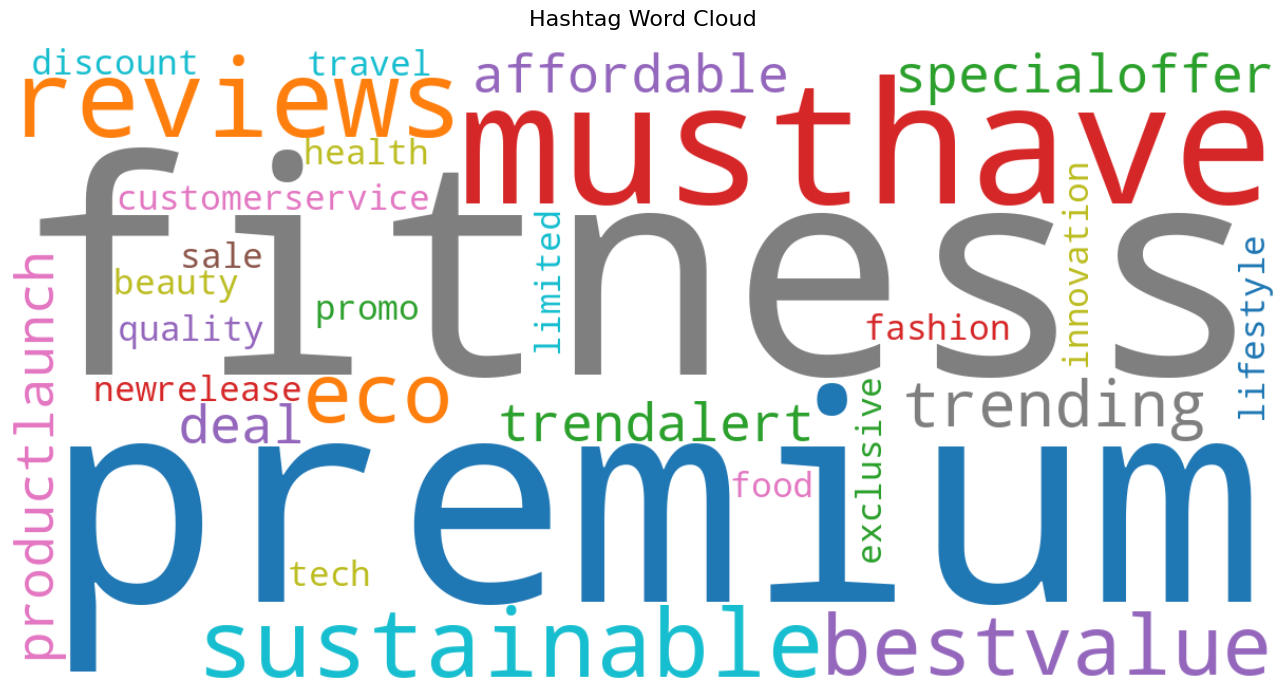

[ANALYSIS 2] Saved: hashtag_wordcloud.png


In [51]:
# -------------------------------------------------------------
# WORD CLOUD OF HASHTAGS
# -------------------------------------------------------------
print("\n[ANALYSIS 2] Generating Hashtag Word Cloud...")
 
freq_dict = {tag.replace("#", ""): count for tag, count in tag_counts.items()}
 
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="tab10",
    max_words=100,
    prefer_horizontal=0.85
).generate_from_frequencies(freq_dict)
 
plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Hashtag Word Cloud", fontsize=16, pad=15)
plt.tight_layout()
plt.savefig("hashtag_wordcloud.png", dpi=150)
plt.show()
print("[ANALYSIS 2] Saved: hashtag_wordcloud.png")


[ANALYSIS 3] Hashtag Count vs. Engagement Rate


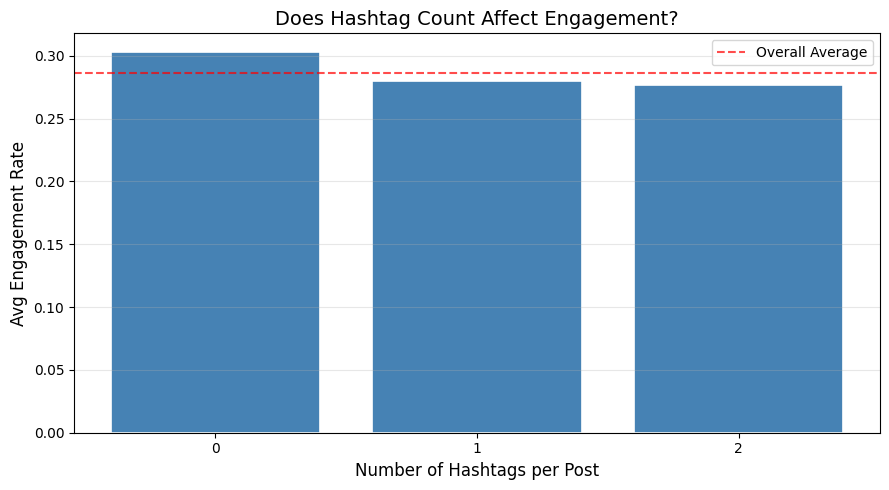

[ANALYSIS 3] Saved: hashtag_count_vs_engagement.png
[ANALYSIS 3] Highest engagement with 0 hashtag(s) per post


In [64]:
# -------------------------------------------------------------
#  HASHTAG COUNT vs. ENGAGEMENT RATE
# -------------------------------------------------------------
print("\n[ANALYSIS 3] Hashtag Count vs. Engagement Rate")

# Bin hashtag counts into groups
max_ct = df_clean["hashtag_count_parsed"].max()
bins   = [0, 1, 2, 3, 4, max(5, max_ct + 1)]
labels = ["0", "1", "2", "3", "5+"]
df_clean["hashtag_bin"] = pd.cut(
    df_clean["hashtag_count_parsed"], bins=bins, labels=labels, right=True
)
 
bin_eng = df_clean.groupby("hashtag_bin")["engagement_rate"].mean().reset_index()
 
plt.figure(figsize=(9, 5))
plt.bar(
    bin_eng["hashtag_bin"].astype(str),
    bin_eng["engagement_rate"],
    color="steelblue", edgecolor="white", linewidth=1.2
)
plt.axhline(df_clean["engagement_rate"].mean(), color="red",
            linestyle="--", alpha=0.7, label="Overall Average")
plt.xlabel("Number of Hashtags per Post", fontsize=12)
plt.ylabel("Avg Engagement Rate", fontsize=12)
plt.title("Does Hashtag Count Affect Engagement?", fontsize=14)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("hashtag_count_vs_engagement.png", dpi=150)
plt.show()
print("[ANALYSIS 3] Saved: hashtag_count_vs_engagement.png")
 
# Print sweet spot
best_bin = bin_eng.loc[bin_eng["engagement_rate"].idxmax(), "hashtag_bin"]
print(f"[ANALYSIS 3] Highest engagement with {best_bin} hashtag(s) per post")



[ANALYSIS 4] Top Hashtags by Avg Engagement Rate
         hashtag  Avg_Engagement  Post_Count
           #food        0.443162         559
      #lifestyle        0.377029         551
           #tech        0.368478         547
        #fitness        0.357043         620
     #newrelease        0.353818         554
       #trending        0.347994         579
         #beauty        0.330939         557
      #bestvalue        0.327330         584
    #sustainable        0.325415         584
         #travel        0.316416         543
#customerservice        0.290834         560
       #musthave        0.284116         584
        #premium        0.277088         589
        #quality        0.274909         529
            #eco        0.270428         581
     #innovation        0.266253         509
         #health        0.262395         558
        #reviews        0.260949         584
  #productlaunch        0.259463         568
           #sale        0.251913         520


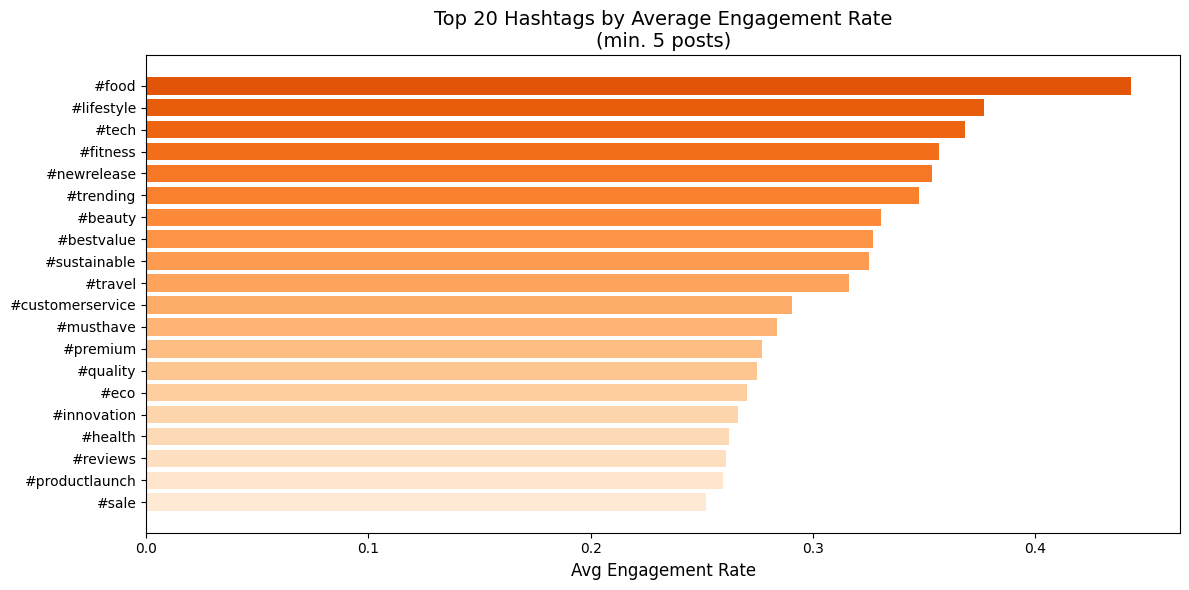

[ANALYSIS 4] Saved: hashtag_top_engagement.png


In [ ]:
# -------------------------------------------------------------
# TOP HASHTAGS BY AVERAGE ENGAGEMENT RATE
# Which specific hashtags drive the most engagement?
# -------------------------------------------------------------

print("\n[ANALYSIS 4] Top Hashtags by Avg Engagement Rate")
 
tag_eng = (
    df_exploded.groupby("hashtag")["engagement_rate"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "Avg_Engagement", "count": "Post_Count"})
)
 # Filter tags with at least 5 posts for statistical reliability
tag_eng = tag_eng[tag_eng["Post_Count"] >= 5].sort_values("Avg_Engagement", ascending=False)
 
top_eng_tags = tag_eng.head(20)
print(top_eng_tags.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_eng_tags["hashtag"][::-1],
    top_eng_tags["Avg_Engagement"][::-1],
    color=cm.Oranges_r(np.linspace(0.3, 0.9, len(top_eng_tags)))[::-1]
)
ax.set_xlabel("Avg Engagement Rate", fontsize=12)
ax.set_title("Top 20 Hashtags by Average Engagement Rate\n(min. 5 posts)", fontsize=14)
plt.tight_layout()
plt.savefig("hashtag_top_engagement.png", dpi=150)
plt.show()
print("[ANALYSIS 4] Saved: hashtag_top_engagement.png")


[ANALYSIS 5] Hashtag Engagement by Platform
         hashtag  engagement_rate
           #food         0.619184
         #beauty         0.547445
         #travel         0.514270
       #musthave         0.491819
            #eco         0.398142
     #newrelease         0.670043
      #lifestyle         0.536815
           #food         0.459185
#customerservice         0.458848
        #reviews         0.427178
      #lifestyle         0.682535
           #food         0.475445
        #fitness         0.426063
   #specialoffer         0.397898
      #bestvalue         0.363845
        #quality         0.609671
       #trending         0.492067
           #deal         0.329704
     #newrelease         0.329666
        #premium         0.325834
           #tech         0.758094
         #travel         0.521362
    #sustainable         0.518031
        #premium         0.442342
       #trending         0.439379


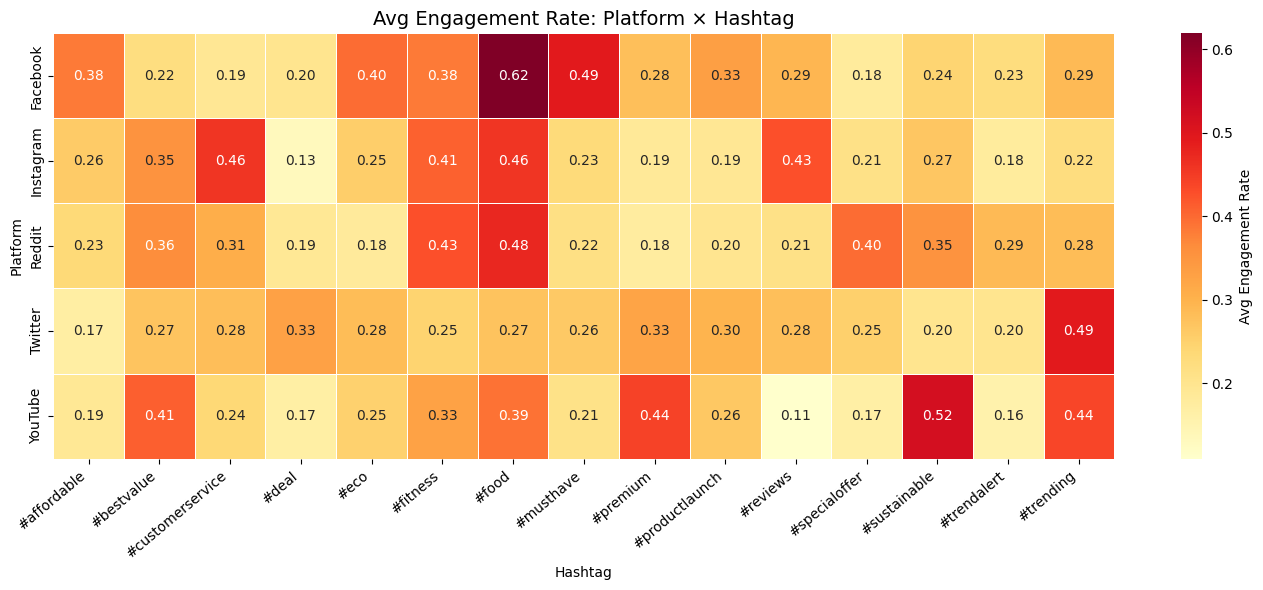

[ANALYSIS 5] Saved: hashtag_platform_heatmap.png


In [69]:
# -------------------------------------------------------------
# HASHTAG PERFORMANCE BY PLATFORM
# Are certain hashtags more effective on specific platforms?
# -------------------------------------------------------------
print("\n[ANALYSIS 5] Hashtag Engagement by Platform")
 
plat_tag = (
    df_exploded.groupby(["platform", "hashtag"])["engagement_rate"]
    .mean()
    .reset_index()
)
# Top 5 hashtags per platform
top_per_platform = (
    plat_tag.groupby("platform")
    .apply(lambda x: x.nlargest(5, "engagement_rate"))
    .reset_index(drop=True)
)
print(top_per_platform.to_string(index=False))

# Heatmap: top overall hashtags × platforms
top_15_tags = [t for t, _ in tag_counts.most_common(15)]
pivot = (
    df_exploded[df_exploded["hashtag"].isin(top_15_tags)]
    .groupby(["platform", "hashtag"])["engagement_rate"]
    .mean()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    cbar_kws={"label": "Avg Engagement Rate"}
)
plt.title("Avg Engagement Rate: Platform × Hashtag", fontsize=14)
plt.ylabel("Platform")
plt.xlabel("Hashtag")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("hashtag_platform_heatmap.png", dpi=150)
plt.show()
print("[ANALYSIS 5] Saved: hashtag_platform_heatmap.png")

In [79]:
# -------------------------------------------------------------
# INTERACTIVE EXPLORATION WITH PYGWALKER
# -------------------------------------------------------------
print("\n[PYGWALKER] Launching interactive hashtag dashboard...")
print("""
  Suggested charts in PyGWalker:
  ┌──────────────────────────────────────────────────────┐
  │ Chart 1 — Bar:     hashtag (X) vs Avg Engagement (Y) │
  │ Chart 2 — Scatter: hashtag_count_parsed (X) vs       │
  │           Avg Engagement_Rate (Y), Color=Platform    │
  │ Chart 3 — Bar:     hashtag (X) vs Avg Likes (Y)      │
  └──────────────────────────────────────────────────────┘
""")
 
# Per-tag view — most useful for hashtag-level exploration
pyg.walk(df_exploded)


[PYGWALKER] Launching interactive hashtag dashboard...

  Suggested charts in PyGWalker:
  ┌──────────────────────────────────────────────────────┐
  │ Chart 1 — Bar:     hashtag (X) vs Avg Engagement (Y) │
  │ Chart 2 — Scatter: hashtag_count_parsed (X) vs       │
  │           Avg Engagement_Rate (Y), Color=Platform    │
  │ Chart 3 — Bar:     hashtag (X) vs Avg Likes (Y)      │
  └──────────────────────────────────────────────────────┘



Box(children=(HTML(value='\n<div id="ifr-pyg-00065001e0cfc26dmiOEcLQvAjp4VtP0" style="height: auto">\n    <hea…